In [58]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
import numpy as np
import matplotlib.pyplot as plt

import OscTools as micro
import OscTools.plot_tools as pt

import OscTools.param_scan as param_scan
import uproot

In [60]:
from scipy.stats import chi2
levels_sigmas_2dof = [chi2.ppf(0.682689492137086, 2), chi2.ppf(0.954499736103642, 2), chi2.ppf(0.997300203936740, 2), chi2.ppf(0.999936657516334, 2)]
levels_sigmas_3dof = [chi2.ppf(0.682689492137086, 3), chi2.ppf(0.954499736103642, 3), chi2.ppf(0.997300203936740, 3), chi2.ppf(0.999936657516334, 3)]
level_95CL_2dof = [chi2.ppf(0.95, 2)]
level_95CL_3dof = [chi2.ppf(0.95, 3)]
print(level_95CL_2dof)

[np.float64(5.99146454710798)]


In [61]:
def load_scan_data(filename):
    data = param_scan.pickle_read(filename)
    
    data_dic = {}
    data_dic['Ue4SQR'] = data[:,2]
    data_dic['Umu4SQR'] = data[:,3]
    s2t = 4*data_dic['Ue4SQR']*data_dic['Umu4SQR']
    data_dic['sin2theta'] = np.round(s2t, decimals=6)
    data_dic['dm4SQR'] = data[:,1]**2
    
    data_dic['MiniApp_chi2'] =  data[:,-3]
    data_dic['MicroApp_chi2'] =  data[:,-2]
    data_dic['MicroApp_Asimov_chi2'] = data[:,-1] 

    data_dic['MiniApp_deltachi2'] = data_dic['MiniApp_chi2'] - np.min(data_dic['MiniApp_chi2'])
    data_dic['MicroApp_deltachi2'] = data_dic['MicroApp_chi2'] - np.min(data_dic['MicroApp_chi2'])
    data_dic['MicroApp_Asimov_deltachi2'] = data_dic['MicroApp_Asimov_chi2'] - np.min(data_dic['MicroApp_Asimov_chi2'])

    return data_dic



def load_scan_data_sbn(filename):
    data = param_scan.pickle_read(filename)
    
    data_dic = {}
    data_dic['Ue4SQR'] = data[:,2]
    data_dic['Umu4SQR'] = data[:,3]
    s2t = 4*data_dic['Ue4SQR']*data_dic['Umu4SQR']
    data_dic['sin2theta'] = np.round(s2t, decimals=6)
    data_dic['dm4SQR'] = data[:,1]**2
    
    data_dic['SBN_chi2'] =  data[:,-1]
    data_dic['SBN_deltachi2'] = data_dic['SBN_chi2'] - np.min(data_dic['SBN_chi2'])

    return data_dic


In [62]:
## PROSPECT stuff

In [63]:
def load_prospect_data():
    #import uproot
    file = uproot.open('ProspectTools/PI_DeltaChiSq.root')
    # Access a specific tree within the file
    tree = file['DeltaChiSq;1']
    tree_np = tree.to_numpy()
    col_deltaChiSq, sinTheta14Sq, dm41Sq = tree_np

    sinTheta14Sq = sinTheta14Sq[:-1] + np.diff(sinTheta14Sq)/2
    dm41Sq = dm41Sq[:-1] + np.diff(dm41Sq)/2
    #print(sinTheta14Sq.shape, dm41Sq.shape, col_deltaChiSq.shape)
    XX, YY = np.meshgrid(sinTheta14Sq, dm41Sq)

    return XX, YY, col_deltaChiSq.T

In [64]:
from scipy.interpolate import griddata
def interpolate_prospect_data(XX, YY, ZZ, XXI, YYI):
    # XXI and YYI are the grid you want to interpolate onto
    return griddata((XX.flatten(), YY.flatten()), ZZ.flatten(), (XXI, YYI), method='cubic', fill_value=0)

## Original PROSPECT data

[]

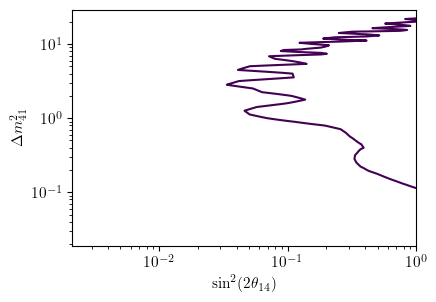

In [65]:
x, y, z = load_prospect_data()
plt.contour(x, y, z, levels=level_95CL_2dof)
plt.xlabel(r'$\sin^2(2\theta_{14})$')
plt.ylabel(r'$\Delta m^2_{41}$')
plt.loglog()

## Interpolated PROSPECT data (use MicroBooNE grid)

[]

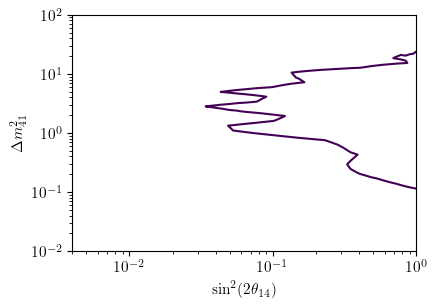

In [66]:
data_dic = load_scan_data('fit_data/fits_before_May6/MH_numu_MC_keep_numu_norm.pkl')
y_int = np.unique(data_dic['dm4SQR'])
Ue4SQR = np.unique(data_dic['Ue4SQR'])
Um4SQR = np.unique(data_dic['Umu4SQR'])
x_int = 4*Ue4SQR*(1-Ue4SQR)
x_int, y_int = np.meshgrid(x_int, y_int)
x, y, z = load_prospect_data()
z_int = interpolate_prospect_data(x, y, z, x_int, y_int)
plt.contour(x_int, y_int, z_int, levels=level_95CL_2dof)
plt.xlabel(r'$\sin^2(2\theta_{14})$')
plt.ylabel(r'$\Delta m^2_{41}$')
plt.loglog()

[]

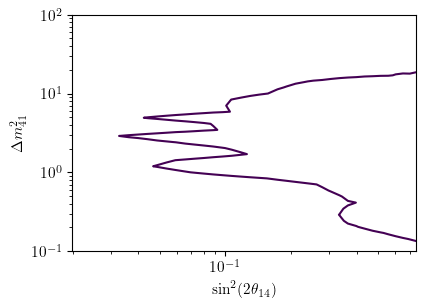

In [67]:
dic_sbn_fullosc = load_scan_data_sbn('fit_data/SBN_fullosc_40.pkl')

y_int = np.unique(dic_sbn_fullosc['dm4SQR'])
Ue4SQR = np.unique(dic_sbn_fullosc['Ue4SQR'])
Um4SQR = np.unique(dic_sbn_fullosc['Umu4SQR'])
x_int = 4*Ue4SQR*(1-Ue4SQR)
x_int, y_int = np.meshgrid(x_int, y_int)
x, y, z = load_prospect_data()
z_int = interpolate_prospect_data(x, y, z, x_int, y_int)
plt.contour(x_int, y_int, z_int, levels=level_95CL_2dof)
plt.xlabel(r'$\sin^2(2\theta_{14})$')
plt.ylabel(r'$\Delta m^2_{41}$')
plt.loglog()

## contour that excludes the point where both Um4sq and Ue4sq = 0.5

In [68]:
y_int = np.unique(data_dic['dm4SQR'])
Ue4SQR = np.unique(data_dic['Ue4SQR'])
# delete the last element to match the dimension of chi2
Ue4SQR = Ue4SQR[:-1]
Um4SQR = np.unique(data_dic['Umu4SQR'])
x_int = 4*Ue4SQR*(1-Ue4SQR)
x_int, y_int = np.meshgrid(x_int, y_int)
x, y, z = load_prospect_data()
z_int_2450 = interpolate_prospect_data(x, y, z, x_int, y_int)


In [69]:
PROS_chi2_nan = z_int.T.flatten()
PROS_chi2 = np.nan_to_num(PROS_chi2_nan, nan=0)

PROS_chi2_2450_nan = z_int_2450.T.flatten()
PROS_chi2_2450 = np.nan_to_num(PROS_chi2_2450_nan, nan=0)
# print(PROS_chi2.shape)
print(PROS_chi2_2450.shape)
def choose_PROS_chi2(i):
    if i == 8:
        return PROS_chi2_2450
    return PROS_chi2

(2450,)


In [70]:
data = param_scan.pickle_read(f"fit_data/fits_before_May6/MH_numu_MC_keep_numu_norm.pkl")
print(data.shape)

(124950, 7)


In [71]:
def make_sin2thetaemu_plot_comparison(dic, name='default'):
    f = [0.18, 0.16, 0.77, 0.76]
    fig, ax1 = pt.std_fig(figsize=(3.7, 3.5), ax_form=f)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel(r"$\sin^2(2\theta_{\mu e})$", fontproperties=pt.font)
    ax1.set_ylabel(r'$\Delta m_{41}^2 [\mathrm{eV^2}]$', fontproperties=pt.font)
    
    kwargs_interp = {'fine_gridx': len(np.unique(dic['sin2theta'])),  
                    'fine_gridy': len(np.unique(dic['dm4SQR'])), 
                    'logx':True, 
                    'logy':True}
    X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MiniApp_deltachi2'], **kwargs_interp)
    cs = ax1.contourf(X,Y,Z, levels=[0, 11.83, 19.33], colors=['orange','peachpuff'], zorder=1, alpha=0.75)
    cs = ax1.contour(X,Y,Z, levels=[11.83, 19.33], colors=['black','black'], linewidths=0.25, zorder=1, alpha=0.75)

    ax1.fill([], [], edgecolor='black', facecolor='orange', lw=0.25, label='this work - $3 \sigma$')
    ax1.fill([], [], edgecolor='black', facecolor='peachpuff', lw=0.25, label='this work - $4 \sigma$')
    return fig, ax1

In [244]:
def profile_for_sin2theta(data_dic, **kwargs):
    dic_prof = {}
    # Profile each chi2
    dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['MiniApp_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['MiniApp_deltachi2'], **kwargs)
    dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['MicroApp_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['MicroApp_deltachi2'], **kwargs)
    dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['MicroApp_Asimov_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['MicroApp_Asimov_deltachi2'], **kwargs)
    if 'PROS_deltachi2' in data_dic.keys():
        dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['PROS_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['PROS_deltachi2'], **kwargs)
    if 'MicroPROS_deltachi2' in data_dic.keys():
        dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['MicroPROS_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['MicroPROS_deltachi2'], **kwargs)
    if 'MicroPROS_Asimov_deltachi2' in data_dic.keys():
        dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['MicroPROS_Asimov_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['MicroPROS_Asimov_deltachi2'], **kwargs)
    
    return dic_prof

def profile_for_sin2theta_sbn(data_dic):
    dic_prof = {}
    # Profile each chi2

    for key in data_dic.keys():
        if not (key == 'sin2theta' or key == 'dm4SQR'):
            dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof[key] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic[key])
    
    return dic_prof

In [247]:
# Load Mini and Micro fits
data_dic = load_scan_data('fit_data/fits_before_May6/MH_numu_MC_keep_numu_norm.pkl')

# Add PROSPECT chi2
x, y, z = load_prospect_data()
data_dic['PROS_chi2'] = interpolate_prospect_data(x, y, z, 4*data_dic['Ue4SQR']*(1 - data_dic['Ue4SQR']), data_dic['dm4SQR'])
data_dic['PROS_deltachi2'] = data_dic['PROS_chi2'] - np.nanmin(data_dic['PROS_chi2'])

data_dic['MicroPROS_chi2'] = data_dic['PROS_chi2'] + data_dic['MicroApp_chi2']
data_dic['MicroPROS_Asimov_chi2'] = data_dic['PROS_chi2'] + data_dic['MicroApp_Asimov_chi2']
data_dic['MicroPROS_deltachi2'] = data_dic['MicroPROS_chi2'] - np.nanmin(data_dic['MicroPROS_chi2'])
data_dic['MicroPROS_Asimov_deltachi2'] = data_dic['MicroPROS_Asimov_chi2'] - np.nanmin(data_dic['MicroPROS_Asimov_chi2'])

# Profile to get sin2theta_emu
# kwargs = {"profile_over_diff_chi2": data_dic['MiniApp_deltachi2']}
kwargs={}
profiled_dic = profile_for_sin2theta(data_dic, **kwargs)

In [226]:

dic_sbn_apponly = profile_for_sin2theta_sbn(load_scan_data_sbn('fit_data/SBN_apponly_50.pkl'))
dic_sbn_stats = profile_for_sin2theta_sbn(load_scan_data_sbn('fit_data/SBN_apponly_statsonly_50.pkl'))
dic_sbn_fullosc = profile_for_sin2theta_sbn(load_scan_data_sbn('fit_data/SBN_fullosc_100.pkl'))


In [227]:
# Load Mini and Micro fits
data_sbn_fullosc = load_scan_data_sbn('fit_data/SBN_fullosc_100.pkl')

# Add PROSPECT chi2
x, y, z = load_prospect_data()
data_sbn_fullosc['PROS_chi2'] = interpolate_prospect_data(x, y, z, 4*data_sbn_fullosc['Ue4SQR']*(1 - data_sbn_fullosc['Ue4SQR']), data_sbn_fullosc['dm4SQR'])
data_sbn_fullosc['PROS_deltachi2'] = data_sbn_fullosc['PROS_chi2'] - np.nanmin(data_sbn_fullosc['PROS_chi2'])

data_sbn_fullosc['SBNPROS_chi2'] = data_sbn_fullosc['PROS_chi2'] + data_sbn_fullosc['SBN_chi2']
data_sbn_fullosc['SBNPROS_deltachi2'] = data_sbn_fullosc['SBNPROS_chi2'] - np.nanmin(data_sbn_fullosc['SBNPROS_chi2'])

# Profile to get sin2theta_emu
# kwargs = {"profile_over_diff_chi2": data_dic['MiniApp_deltachi2']}
kwargs={}
profiled_dic_sbn = profile_for_sin2theta_sbn(data_sbn_fullosc, **kwargs)

# FIG 1 

In [552]:
def make_sin2thetaemu_plot(ax1, dic, dic_sbn, define_sthetamue=True, name='default', asimov=False, cmap_color='steelblue', n_sigmas=4, cmin=0.05, cmax=0.95, chi2=None, sigma_min=1, Microcolor='black', MicroPROScolor='firebrick', xy_MB=[0.11, 0.92]):
    ax1.set_xscale('log')
    ax1.set_yscale('log')

    if define_sthetamue:
        ax1.set_xlabel(r"$\sin^2(2\theta_{\mu e}) = 4 |U_{e4}|^2 |U_{\mu 4}|^2 $", fontproperties=pt.font)
    else:
        ax1.set_xlabel(r"$\sin^2(2\theta_{\mu e})$", fontproperties=pt.font)
    ax1.set_ylabel(r'$\Delta m_{41}^2 [\mathrm{eV^2}]$', fontproperties=pt.font)

    kwargs_interp = {'fine_gridx': len(np.unique(dic['sin2theta'])),  
                    'fine_gridy': len(np.unique(dic['dm4SQR'])), 
                    'logx':True, 
                    'logy':True}

    if chi2:
        MB_chi2 = [0, chi2]
        colors = ['orange']
    else:
        MB_chi2 = pt.get_chi2vals_w_nsigmas(n_sigmas, 2, sigma_min=sigma_min)
        print(MB_chi2)
        colors = pt.get_cmap_colors(cmap_color, n_sigmas, cmin=cmin, cmax=cmax)

    X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MiniApp_deltachi2'], **kwargs_interp)
    cs = ax1.contourf(X,Y,Z, levels=[0]+MB_chi2, colors=colors, zorder=1, alpha=1)
    # cs = ax1.contour(X,Y,Z, levels=MB_chi2, colors=['black'], linewidths=0.01, zorder=1, alpha=1)
    # ax1.scatter(dic['Umu4SQR'], dic['dm4SQR'], c=np.log10(dic['MiniApp_chi2']-np.min(dic['MiniApp_chi2'])),)
    ax1.scatter(X.flatten()[np.nanargmin(Z)], Y.flatten()[np.nanargmin(Z)], marker='*', facecolor='black', edgecolor='black', lw=0.5, zorder=10)

    if chi2:
        muB_chi2 = [chi2] 
    else:
        muB_chi2 = [5.99] # 95% CL for 2 dof

    X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MicroApp_deltachi2'], **kwargs_interp)
    _ = ax1.contour(X,Y,Z, levels=muB_chi2, colors=[Microcolor], linewidths=[1.5], zorder=2)

    X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MicroPROS_deltachi2'], **kwargs_interp)
    _ = ax1.contour(X,Y,Z, levels=muB_chi2, colors=[MicroPROScolor], zorder=2, linewidths=[1.5])
    
    if asimov:
        X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MicroApp_Asimov_deltachi2'], **kwargs_interp)
        cs = ax1.contour(X,Y,Z, levels=muB_chi2, colors=[Microcolor], zorder=2, linewidths=[1.], linestyles=[(1,(3,0.5))])
        
        X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MicroPROS_Asimov_deltachi2'], **kwargs_interp)
        cs = ax1.contour(X,Y,Z, levels=muB_chi2, colors=[MicroPROScolor], zorder=2, linewidths=[1.], linestyles=[(1,(3,0.5))])
    
    # X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['PROS_deltachi2'], **kwargs_interp)
    # cs = ax1.contour(X,Y,Z, levels=muB_chi2, colors=[Microcolor], linewidths=[1], linestyles=[(1,(1,1))], zorder=2)
    
    # X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['PROS_deltachi2'], **kwargs_interp)
    # cs = ax1.contour(X,Y,Z, levels=muB_chi2, colors=['grey'], zorder=2, linewidths=[1], linestyles=[(1,(2,1))])
    

    ax1.plot([], [], color=Microcolor, lw=1.5, label='$\mu$B')
    ax1.plot([], [], color=Microcolor, lw=1., ls=(1,(3,0.5)), label='$\mu$B (Asimov)')
    ax1.plot([], [], color=MicroPROScolor, lw=1.5, label='$\mu$B+PROS')
    ax1.plot([], [], color=MicroPROScolor, lw=1., ls=(1,(3,0.5)), label='$\mu$B+PROS (Asimov)')
    
    # ax1.plot([], [], color='grey', lw=1., ls=(1,(2,1)), label='PROS')
    
    # x,y=np.genfromtxt('MicroTools/muB_data/official/official_contour.dat', unpack=True)
    # l1=ax1.plot(x,y, ls='-', color='red', label=r'$\mu$B 2022 (BNB)')
    # x,y=np.genfromtxt('MicroTools/muB_data/official/BNB_and_NUMI_sensitivity.dat', unpack=True)
    # l3=ax1.plot(x,y, ls=(1,(1,1)), lw=1.5, color='red', label=r'$\mu$B 2022 (BNB+NuMI) sens')
    # x,y=np.genfromtxt('MicroTools/muB_data/official/app_only_2022_official.dat', unpack=True)
    # l2=ax1.plot(x,y, ls=(1,(1,0.5)), lw=1, color='red', label=r'$\mu$B 2022 (BNB app-only)')
    
    # ------ get the legend-entries that are already attached to the axis
    if xy_MB is not None:
        mb_label = r'('+', '.join([fr'${sigma_min+i}$' for i in range(n_sigmas)])+')$\sigma$'
        leg1 = ax1.legend([pt.MulticolorPatch(colors)], ['MB'], loc=(0.01,0.92), fontsize=9.5, handler_map={pt.MulticolorPatch: pt.MulticolorPatchHandler()})
        ax1.add_artist(leg1)
        ax1.annotate(mb_label, xy=(xy_MB[0]-0.09, xy_MB[1]-0.05), xycoords='axes fraction', fontsize=9.5)
    # leg2 = ax1.legend(h, l, loc=(0,0), fontsize=9.5, ncol=2, handler_map={pt.MulticolorPatch: pt.MulticolorPatchHandler()}, title=r'$95\%$ CL exclusions/sensitivity:', title_fontsize=9)
    h, l = ax1.get_legend_handles_labels()
    leg2 = ax1.legend(h, l, loc=(0,0), fontsize=9.5, ncol=1, handler_map={pt.MulticolorPatch: pt.MulticolorPatchHandler()}, title=r'$95\%$ CL exclusion', title_fontsize=9)
    leg2._legend_box.align = "left"
    # ax1.add_artist(leg2)

    return ax1
    # fig.savefig(f"{micro.path_plots}/MH_full_osc_sin2thetaemuSQR_profiled.pdf", bbox_inches='tight', dpi=300)
    # fig.savefig(f"{micro.path_plots}/MH_full_osc_sin2thetaemuSQR_profiled_{name}.pdf", bbox_inches='tight', dpi=300)



def make_sin2thetaemu_plot_SBN(ax1, dic, dic_sbn, define_sthetamue=True, name='default', asimov=False, cmap_color='steelblue', n_sigmas=4, cmin=0.05, cmax=0.95, chi2=None, sigma_min=1, SBNPROScolor='black', SBNcolor='firebrick', xy_MB=[0.11, 0.92]):
    ax1.set_xscale('log')
    ax1.set_yscale('log')

    if define_sthetamue:
        ax1.set_xlabel(r"$\sin^2(2\theta_{\mu e}) = 4 |U_{e4}|^2 |U_{\mu 4}|^2 $", fontproperties=pt.font)
    else:
        ax1.set_xlabel(r"$\sin^2(2\theta_{\mu e})$", fontproperties=pt.font)
    ax1.set_ylabel(r'$\Delta m_{41}^2 [\mathrm{eV^2}]$', fontproperties=pt.font)
    # ax1.set_xlim(1e-4,0.2)

    kwargs_interp = {'fine_gridx': len(np.unique(dic['sin2theta'])),  
                    'fine_gridy': len(np.unique(dic['dm4SQR'])), 
                    'logx':True, 
                    'logy':True}

    if chi2:
        MB_chi2 = [0, chi2]
        colors = ['orange']
    else:
        MB_chi2 = pt.get_chi2vals_w_nsigmas(n_sigmas, 2, sigma_min=sigma_min)
        print(MB_chi2)
        colors = pt.get_cmap_colors(cmap_color, n_sigmas, cmin=cmin, cmax=cmax)

    X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MiniApp_deltachi2'], **kwargs_interp)
    cs = ax1.contourf(X,Y,Z, levels=[0]+MB_chi2, colors=colors, zorder=1, alpha=1)
    # cs = ax1.contour(X,Y,Z, levels=MB_chi2, colors=['black'], linewidths=0.01, zorder=1, alpha=1)
    # ax1.scatter(dic['Umu4SQR'], dic['dm4SQR'], c=np.log10(dic['MiniApp_chi2']-np.min(dic['MiniApp_chi2'])),)
    ax1.scatter(X.flatten()[np.nanargmin(Z)], Y.flatten()[np.nanargmin(Z)], marker='*', facecolor='black', edgecolor='black', lw=0.5, zorder=10)

    if chi2:
        muB_chi2 = [chi2] 
    else:
        muB_chi2 = [5.99] # 95% CL for 2 dof

    kwargs_interp = {'fine_gridx': len(np.unique(dic_sbn['sin2theta'])),  
                    'fine_gridy': len(np.unique(dic_sbn['dm4SQR'])), 
                    'logx':True, 
                    'logy':True}

    X, Y, Z = pt.interp_grid(dic_sbn['sin2theta'], dic_sbn['dm4SQR'], dic_sbn['SBN_deltachi2'], **kwargs_interp)
    _ = ax1.contour(X,Y,Z, levels=muB_chi2, colors=[SBNcolor], linewidths=[1.5], zorder=2, linestyles=[(1,(3,0.5))])

    X, Y, Z = pt.interp_grid(dic_sbn['sin2theta'], dic_sbn['dm4SQR'], dic_sbn['SBNPROS_deltachi2'], **kwargs_interp)
    _ = ax1.contour(X,Y,Z, levels=muB_chi2, colors=[SBNPROScolor],  linewidths=[1.5], zorder=2, linestyles=[(1,(3,0.5))])
    

    ax1.plot([], [], color=SBNcolor, lw=1.5, ls=(1,(3,0.5)), label='SBN')
    ax1.plot([], [], color=SBNPROScolor, lw=1., ls=(1,(3,0.5)), label='SBN + PROS-II')
    

    # ------ get the legend-entries that are already attached to the axis
    if xy_MB is not None:
        mb_label = r'('+', '.join([fr'${sigma_min+i}$' for i in range(n_sigmas)])+')$\sigma$'
        leg1 = ax1.legend([pt.MulticolorPatch(colors)], ['MB'], loc=(0.01,0.92), fontsize=9.5, handler_map={pt.MulticolorPatch: pt.MulticolorPatchHandler()})
        ax1.add_artist(leg1)
        ax1.annotate(mb_label, xy=(xy_MB[0]-0.09, xy_MB[1]-0.05), xycoords='axes fraction', fontsize=9.5)
    h, l = ax1.get_legend_handles_labels()
    leg2 = ax1.legend(h, l, loc=(0,0), fontsize=9.5, ncol=1, handler_map={pt.MulticolorPatch: pt.MulticolorPatchHandler()}, title=r'$95\%$ CL sensitivity', title_fontsize=9)
    leg2._legend_box.align = "left"

    return ax1


[np.float64(2.295748928898636), np.float64(6.180074306244173), np.float64(11.829158081900795), np.float64(19.333908611934685)]


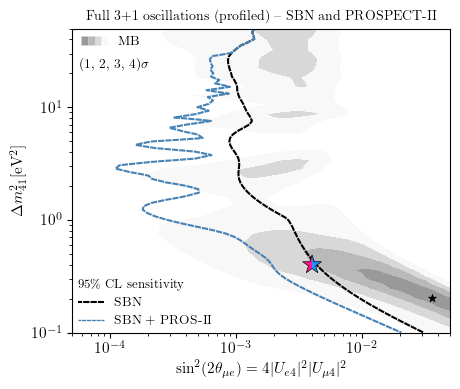

In [553]:
f = [0.14, 0.16, 0.84, 0.76]
fig, ax = pt.std_fig(figsize=(4.5, 4.), ax_form=f)
# fig, ax = make_sin2thetaemu_plot_comparison(dic_numu_MC_keep_numu_norm, name='numu_MC_keep_numu_norm')

ax = make_sin2thetaemu_plot_SBN(ax, profiled_dic, profiled_dic_sbn, name='numu_MC_keep_numu_norm', 
                            asimov=True, 
                            cmap_color='grey', 
                            n_sigmas=4, 
                            sigma_min=1, 
                            cmax=0.97, 
                            cmin=0.6, 
                            SBNcolor='black',
                            SBNPROScolor='steelblue')

from matplotlib.markers import MarkerStyle

ax.scatter(4e-3, 0.4, facecolor='dodgerblue', edgecolor='None', marker=MarkerStyle("*", fillstyle="right"), lw=1, zorder=10, s=200)
ax.scatter(4e-3, 0.4, facecolor='deeppink', edgecolor='None', marker=MarkerStyle("*", fillstyle="left"), lw=1, zorder=10, s=200)
ax.scatter(4e-3, 0.4, facecolor='None', edgecolor='black', marker='*', lw=0.5, zorder=10, s=200)

ax.set_xlim(0.5e-4,0.05)
ax.set_ylim(10e-2,50)
ax.set_title(r'Full 3+1 oscillations (profiled) -- SBN and PROSPECT-II', fontsize=10)
fig.savefig(f"{micro.path_plots}/fullosc_prospect_micro.pdf", dpi=300)
fig.savefig(f"{micro.path_plots}/main_profiled_to_slice_comparison_1.pdf", dpi=300)

[np.float64(2.295748928898636), np.float64(6.180074306244173), np.float64(11.829158081900795), np.float64(19.333908611934685)]


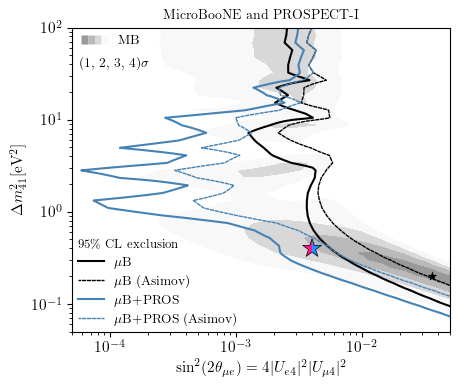

In [554]:
f = [0.2, 0.16, 0.84, 0.76]
fig, ax = pt.std_fig(figsize=(4.5, 4.), ax_form=f)
# fig, ax = make_sin2thetaemu_plot_comparison(dic_numu_MC_keep_numu_norm, name='numu_MC_keep_numu_norm')

ax = make_sin2thetaemu_plot(ax, profiled_dic, profiled_dic_sbn, name='numu_MC_keep_numu_norm', 
                            asimov=True, 
                            cmap_color='grey', 
                            n_sigmas=4, 
                            sigma_min=1, 
                            cmax=0.97, 
                            cmin=0.6, 
                            MicroPROScolor='steelblue', 
                            Microcolor='black')


from matplotlib.markers import MarkerStyle

ax.scatter(4e-3, 0.4, facecolor='dodgerblue', edgecolor='None', marker=MarkerStyle("*", fillstyle="right"), lw=1, zorder=10, s=200)
ax.scatter(4e-3, 0.4, facecolor='deeppink', edgecolor='None', marker=MarkerStyle("*", fillstyle="left"), lw=1, zorder=10, s=200)
ax.scatter(4e-3, 0.4, facecolor='None', edgecolor='black', marker='*', lw=0.5, zorder=10, s=200)

ax.set_xlim(0.5e-4,0.05)
ax.set_ylim(5e-2,100)
ax.set_title(r'MicroBooNE and PROSPECT-I', fontsize=10)
fig.savefig(f"{micro.path_plots}/fullosc_prospect_micro.pdf", dpi=300)
fig.savefig(f"{micro.path_plots}/main_profiled_to_slice_comparison_1.pdf", dpi=300)

[np.float64(2.295748928898636), np.float64(6.180074306244173), np.float64(11.829158081900795), np.float64(19.333908611934685)]
[np.float64(2.295748928898636), np.float64(6.180074306244173), np.float64(11.829158081900795), np.float64(19.333908611934685)]


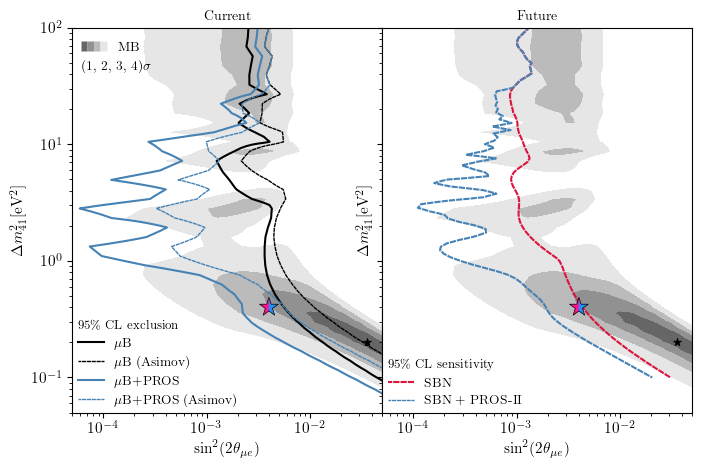

In [561]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={'width_ratios': [1, 1], 'wspace': 0}, sharey=True)

ax1 = make_sin2thetaemu_plot(ax1, profiled_dic, profiled_dic_sbn, name='numu_MC_keep_numu_norm', 
                            asimov=True, 
                            cmap_color='grey', 
                            n_sigmas=4, 
                            sigma_min=1, 
                            cmax=0.9, 
                            cmin=0.4, 
                            Microcolor='black',
                            MicroPROScolor='steelblue', 
                            define_sthetamue=False,
                            xy_MB=[0.12, 0.94])


ax2 = make_sin2thetaemu_plot_SBN(ax2, profiled_dic, profiled_dic_sbn, name='numu_MC_keep_numu_norm', 
                            asimov=True, 
                            cmap_color='grey', 
                            n_sigmas=4, 
                            sigma_min=1, 
                            cmax=0.9, 
                            cmin=0.4, 
                            SBNcolor='crimson',
                            SBNPROScolor='steelblue',
                            define_sthetamue=False,
                            xy_MB=None)


from matplotlib.markers import MarkerStyle

for ax in [ax1, ax2]:
    ax.scatter(4e-3, 0.4, facecolor='dodgerblue', edgecolor='None', marker=MarkerStyle("*", fillstyle="right"), lw=1, zorder=10, s=200)
    ax.scatter(4e-3, 0.4, facecolor='deeppink', edgecolor='None', marker=MarkerStyle("*", fillstyle="left"), lw=1, zorder=10, s=200)
    ax.scatter(4e-3, 0.4, facecolor='None', edgecolor='black', marker='*', lw=0.5, zorder=10, s=200)

    ax.set_xlim(0.5e-4,0.05)
    ax.set_ylim(5e-2,100)
ax1.set_title(r'Current', fontsize=10)
ax2.set_title(r'Future', fontsize=10)

fig.savefig(f"plots/main_profiled_to_slice_comparison_1.pdf", dpi=300, bbox_inches='tight')

[np.float64(2.295748928898636), np.float64(6.180074306244173), np.float64(11.829158081900795), np.float64(19.333908611934685)]
[np.float64(2.295748928898636), np.float64(6.180074306244173), np.float64(11.829158081900795), np.float64(19.333908611934685)]


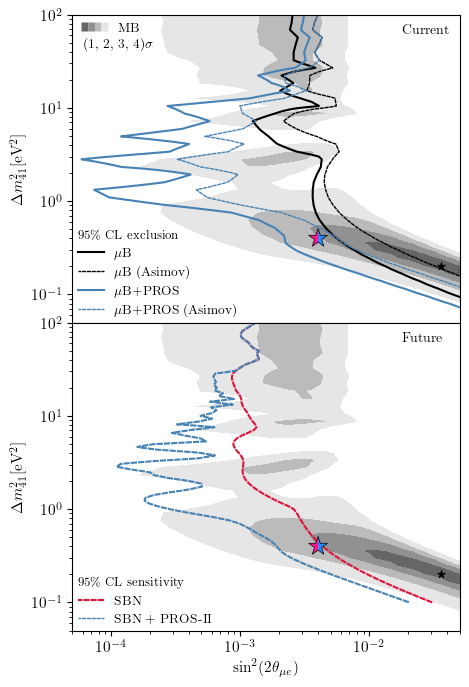

In [562]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 8), gridspec_kw={'height_ratios': [1, 1], 'hspace': 0}, sharex=True)

ax1 = make_sin2thetaemu_plot(ax1, profiled_dic, profiled_dic_sbn, name='numu_MC_keep_numu_norm', 
                            asimov=True, 
                            cmap_color='grey', 
                            n_sigmas=4, 
                            sigma_min=1, 
                            cmax=0.9, 
                            cmin=0.4, 
                            Microcolor='black',
                            MicroPROScolor='steelblue', 
                            define_sthetamue=False,
                            xy_MB=[0.12, 0.94])


ax2 = make_sin2thetaemu_plot_SBN(ax2, profiled_dic, profiled_dic_sbn, name='numu_MC_keep_numu_norm', 
                            asimov=True, 
                            cmap_color='grey', 
                            n_sigmas=4, 
                            sigma_min=1, 
                            cmax=0.9, 
                            cmin=0.4, 
                            SBNcolor='crimson',
                            SBNPROScolor='steelblue',
                            define_sthetamue=False,
                            xy_MB=None)

from matplotlib.markers import MarkerStyle

for ax in [ax1, ax2]:
    ax.scatter(4e-3, 0.4, facecolor='dodgerblue', edgecolor='None', marker=MarkerStyle("*", fillstyle="right"), lw=1, zorder=10, s=200)
    ax.scatter(4e-3, 0.4, facecolor='deeppink', edgecolor='None', marker=MarkerStyle("*", fillstyle="left"), lw=1, zorder=10, s=200)
    ax.scatter(4e-3, 0.4, facecolor='None', edgecolor='black', marker='*', lw=0.5, zorder=10, s=200)

    ax.set_xlim(0.5e-4,0.05)
    ax.set_ylim(5e-2,100)
ax1.annotate(r'Current', fontsize=10, xy=(0.85, 0.94), xycoords='axes fraction')
ax2.annotate(r'Future', fontsize=10, xy=(0.85, 0.94), xycoords='axes fraction')

fig.savefig(f"plots/main_profiled_to_slice_comparison_1.pdf", dpi=300, bbox_inches='tight')

In [ ]:
f = [0.14, 0.16, 0.84, 0.76]
fig, ax = pt.std_fig(figsize=(4.5, 4.), ax_form=f)
# fig, ax = make_sin2thetaemu_plot_comparison(dic_numu_MC_keep_numu_norm, name='numu_MC_keep_numu_norm')

ax = make_sin2thetaemu_plot(ax, profiled_dic, profiled_dic_sbn, name='numu_MC_keep_numu_norm', asimov=False, cmap_color='grey', n_sigmas=4, sigma_min=1, cmax=0.97, cmin=0.6, SBNcolor='deeppink', Microcolor='dodgerblue')

# x,y=np.genfromtxt('MiniTools/include/MB_data_release_2022/miniboone_fit_3sigma_1.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,1)))

# x,y=np.genfromtxt('MiniTools/include/MB_data_release_2022/miniboone_fit_3sigma_2.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,1)), label=r'MB coll. - $3\sigma$')


# x,y=np.genfromtxt('MiniTools/include/MB_data_release_2022/miniboone_fit_4sigma_1.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,0)))

# x,y=np.genfromtxt('MiniTools/include/MB_data_release_2022/miniboone_fit_4sigma_2.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,0)), label=r'MB coll. - $4\sigma$')
from matplotlib.markers import MarkerStyle

ax.scatter(4e-3, 0.4, facecolor='gold', edgecolor='None', marker=MarkerStyle("*", fillstyle="right"), lw=1, zorder=10, s=200)
ax.scatter(4e-3, 0.4, facecolor='green', edgecolor='None', marker=MarkerStyle("*", fillstyle="left"), lw=1, zorder=10, s=200)
ax.scatter(4e-3, 0.4, facecolor='None', edgecolor='black', marker='*', lw=0.5, zorder=10, s=200)

ax.set_xlim(0.5e-4,0.05)
ax.set_ylim(10e-2,50)
ax.set_title(r'Full 3+1 oscillations (profiled)', fontsize=10)
fig.savefig(f"{micro.path_plots}/fullosc_prospect_micro.pdf", dpi=300)
fig.savefig(f"{micro.path_plots}/main_profiled_to_slice_comparison_1.pdf", dpi=300)

Z_slices 0.4291934260128776 0.40370172585965547


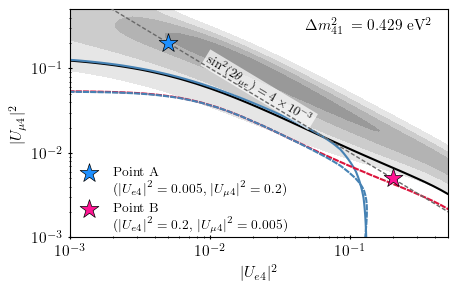

In [598]:
import numpy as np
import matplotlib.pyplot as plt

labels_slices = [r'$g_\varphi$', r'$\Delta m_{41}^2 [\mathrm{eV^2}]$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]
string_slices = [r'$g_\varphi$', r'$\Delta m_{41}^2$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]

var_labels = ['g','dm4SQR', 'Ue4SQR', 'Umu4SQR']

def get_var(data, i):
    if isinstance(data, dict):
        return data[var_labels[i]]
    else:

        if i == 1:
            return data[:, 1]**2
        return data[:, i]

def plot_single_slice(dic, dic_sbn, xi=2, yi=3, zi=1, global_deltachi2=False, z_slice=0.754, n_sigmas=4, cmin=0.05, cmax=0.95, chi2=None, sigma_min=1, cmap_color='steelblue', Microcolor='black', SBNcolor='firebrick',  MicroPROScolor='black', SBNPROScolor='firebrick'):

    data = dic 

    MiniApp_chi2 = dic['MiniApp_chi2'] 
    MicroApp_chi2 = dic['MicroApp_chi2']
    MicroApp_Asimov_chi2 = dic['MicroApp_Asimov_chi2'] 
    MiniApp_deltachi2 = dic['MiniApp_deltachi2']
    MicroApp_deltachi2 = dic['MicroApp_deltachi2']
    MicroApp_Asimov_deltachi2 = dic['MicroApp_Asimov_deltachi2']

    MicroPROS_chi2 = dic['MicroPROS_chi2']
    PROS_chi2 = dic['PROS_chi2']

    x, y, z = get_var(data, xi), get_var(data, yi), get_var(data, zi)
    x_sbn, y_sbn, z_sbn = get_var(dic_sbn, xi), get_var(dic_sbn, yi), get_var(dic_sbn, zi)
    i_min = np.argmin(MiniApp_deltachi2)
    x_min, y_min, z_min = x[i_min], y[i_min], z[i_min]

    i_min_sbn = np.argmin(MiniApp_deltachi2)
    x_min_sbn, y_min_sbn, z_min_sbn = x[i_min_sbn], y[i_min_sbn], z[i_min_sbn]

    # Find the closest slice to the true value
    z_slice_true = z[np.argmin(np.abs(z - z_slice))]
    cut = (z == z_slice_true)

    z_slice_true_sbn = z_sbn[np.argmin(np.abs(z_sbn - z_slice))]
    print("Z_slices", z_slice_true, z_slice_true_sbn)
    cut_sbn = (z_sbn == z_slice_true_sbn)

    f = [0.14, 0.16, 0.84, 0.76]
    fig, ax = pt.std_fig(figsize=(4.5, 3.), ax_form=f)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis="both", which='both', direction="inout", left="off", labelleft="on", zorder=10, labelsize=11)

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())

    ax.set_ylabel(string_slices[yi], fontproperties=pt.font)
    ax.set_xlabel(string_slices[xi], fontproperties=pt.font)

    kwargs_interp = {
        'fine_gridx': len(np.unique(x)),
        'fine_gridy': len(np.unique(y)),
        'logx': True,
        'logy': True,
        'method': 'triangulation'
    }

    ################
    # MINIBOONE
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MiniApp_chi2'][cut] - np.min(dic['MiniApp_chi2']), **kwargs_interp)
        MB_chi2 = pt.get_chi2vals_w_nsigmas(n_sigmas, 3, sigma_min=sigma_min)
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MiniApp_chi2'][cut] - np.min(dic['MiniApp_chi2'][cut]), **kwargs_interp)
        MB_chi2 = pt.get_chi2vals_w_nsigmas(n_sigmas, 2, sigma_min=sigma_min)

    colors = pt.get_cmap_colors(cmap_color, n_sigmas, cmin=cmin, cmax=cmax)
    cs = ax.contourf(X,Y,Z, levels=[0]+MB_chi2, colors=colors, zorder=1, alpha=1)
    # cs = ax.contour(X,Y,Z, levels=MB_chi2, colors=['black'], linewidths=0.25, zorder=1, alpha=1)
    
    ################
    # MICRO 
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MicroApp_chi2'][cut] - np.min(dic['MicroApp_chi2']), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MicroApp_chi2'][cut] - np.min(dic['MicroApp_chi2'][cut]), **kwargs_interp)

    level_MicroBooNE = [5.99]
    cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=[Microcolor], zorder=2, linestyles=[(1,(3,0))])

    ################
    # MICRO + PROSPECT
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MicroPROS_chi2'][cut] - np.min(dic['MicroPROS_chi2']), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MicroPROS_chi2'][cut] - np.min(dic['MicroPROS_chi2'][cut]), **kwargs_interp)
    cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=[MicroPROScolor], zorder=2, linestyles=[(1,(3,0))])
    

    ################
    # SBN 
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x_sbn[cut_sbn], y_sbn[cut_sbn], dic_sbn['SBN_chi2'][cut_sbn] - np.min(dic_sbn['SBN_chi2']), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x_sbn[cut_sbn], y_sbn[cut_sbn], dic_sbn['SBN_chi2'][cut_sbn] - np.min(dic_sbn['SBN_chi2'][cut_sbn]), **kwargs_interp)
    cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=[SBNcolor], zorder=2, linestyles=[(1,(3,0.5))])
    
    ################
    # SBN + PROSPECT
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x_sbn[cut_sbn], y_sbn[cut_sbn], dic_sbn['SBNPROS_chi2'][cut_sbn] - np.min(dic_sbn['SBNPROS_chi2']), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x_sbn[cut_sbn], y_sbn[cut_sbn], dic_sbn['SBNPROS_chi2'][cut_sbn] - np.min(dic_sbn['SBNPROS_chi2'][cut_sbn]), **kwargs_interp)
    cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=[SBNPROScolor], zorder=2, linestyles=[(1,(3,0.5))])
    
    ################
    # PROSPECT
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], PROS_chi2[cut] - np.min(PROS_chi2), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], PROS_chi2[cut] - np.min(PROS_chi2[cut]), **kwargs_interp)
    # cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=['black'], zorder=2, linestyles=[(1,(1,1))])
    

    if z_min == z_slice:
        ax.scatter(x_min, y_min, marker='*', facecolor='black', edgecolor='black', lw=0.25, zorder=10)

    # ax.fill([], [], edgecolor='black', facecolor='orange', lw=0.25, label=rf'MB ($\Delta \chi^2_{{\rm MB}} = {DELTACHI2_THRESHOLD}$)')
    # ax.plot([], [], color='black', lw=1.5, label=rf'$\mu$B ($95\%$ CL)')
    #ax.plot([], [], color='black', lw=1.5, ls='--', label='$\mu$B (Asimov) 95\% CL')
    ax.plot(np.linspace(x.min(), x.max(), 100), 0.0005*2/np.linspace(x.min(), x.max(), 100), color='dimgrey', lw=1, ls=(1,(3,1.5)), zorder=10)
    ax.annotate(text=r'$\sin^2(2 \theta_{\mu e})= 4\times 10^{-3}$', 
                xy=(3e-3*3, 0.46/3), 
                xycoords='data', 
                fontsize=9., 
                color='black', 
                ha='left', 
                va='top', 
                rotation=-31, 
                bbox=dict(facecolor='white', 
                          edgecolor='None', 
                          alpha=0.7,
                          boxstyle='square,pad=0.2')
                )
    ax.annotate(text=fr"{string_slices[zi]} $\,= {z_slice_true:.3f}$ eV$^2$", 
                xycoords='axes fraction', 
                xy=(0.62, 0.91), 
                fontsize=11, 
                bbox=dict(facecolor='white', edgecolor='None', alpha=0.9, boxstyle='round'))

    ax.scatter(0.02/4, 0.05*4, marker='*', facecolor='dodgerblue', edgecolor='black', lw=0.5, zorder=10, s=200, label = r'\noindent Point A  \\($|U_{e4}|^2 = 0.005$, $|U_{\mu4}|^2 = 0.2$)')
    ax.scatter(0.2, 0.005, marker='*', facecolor='deeppink', edgecolor='black', lw=0.5, zorder=10, s=200, label = r'\noindent Point B  \\($|U_{e4}|^2 = 0.2$, $|U_{\mu4}|^2 = 0.005$)')
    ax.legend(loc=(0, 0), fontsize=9.5)

    ax.set_ylim(1e-3,0.5)
    ax.set_xlim(1e-3,0.5)

    # fig.savefig(f"{micro.path_plots}/Micro_single_slice_{xi}_{yi}_{zi}{'_global' if global_deltachi2 else ''}.pdf", bbox_inches='tight', dpi=300)
    fig.savefig(f"{micro.path_plots}/main_profiled_to_slice_comparison_2.pdf", dpi=300)

plot_single_slice(data_dic, data_sbn_fullosc, xi=2, yi=3, zi=1, global_deltachi2=False, z_slice=0.4, n_sigmas=4, sigma_min=1, cmax=0.9, cmin=0.6, cmap_color='grey', SBNcolor='crimson', Microcolor='black', SBNPROScolor='steelblue', MicroPROScolor='steelblue')

Z_slices 2.8117686979742276 3.0538555088334154


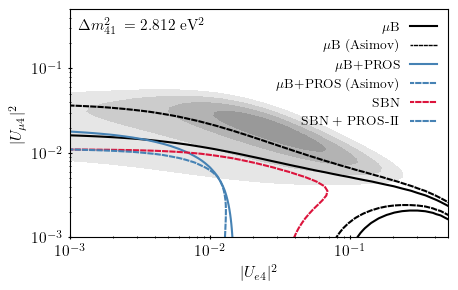

In [623]:
import numpy as np
import matplotlib.pyplot as plt

labels_slices = [r'$g_\varphi$', r'$\Delta m_{41}^2 [\mathrm{eV^2}]$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]
string_slices = [r'$g_\varphi$', r'$\Delta m_{41}^2$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]

var_labels = ['g','dm4SQR', 'Ue4SQR', 'Umu4SQR']

def get_var(data, i):
    if isinstance(data, dict):
        return data[var_labels[i]]
    else:

        if i == 1:
            return data[:, 1]**2
        return data[:, i]

def plot_single_slice(dic, dic_sbn, xi=2, yi=3, zi=1, global_deltachi2=False, z_slice=0.754, n_sigmas=4, cmin=0.05, cmax=0.95, chi2=None, sigma_min=1, cmap_color='steelblue', Microcolor='black', SBNcolor='firebrick',  MicroPROScolor='black', SBNPROScolor='firebrick'):

    data = dic 

    MiniApp_chi2 = dic['MiniApp_chi2'] 
    MicroApp_chi2 = dic['MicroApp_chi2']
    MicroApp_Asimov_chi2 = dic['MicroApp_Asimov_chi2'] 
    MiniApp_deltachi2 = dic['MiniApp_deltachi2']
    MicroApp_deltachi2 = dic['MicroApp_deltachi2']
    MicroApp_Asimov_deltachi2 = dic['MicroApp_Asimov_deltachi2']

    MicroPROS_chi2 = dic['MicroPROS_chi2']
    PROS_chi2 = dic['PROS_chi2']

    x, y, z = get_var(data, xi), get_var(data, yi), get_var(data, zi)
    x_sbn, y_sbn, z_sbn = get_var(dic_sbn, xi), get_var(dic_sbn, yi), get_var(dic_sbn, zi)
    i_min = np.argmin(MiniApp_deltachi2)
    x_min, y_min, z_min = x[i_min], y[i_min], z[i_min]

    i_min_sbn = np.argmin(MiniApp_deltachi2)
    x_min_sbn, y_min_sbn, z_min_sbn = x[i_min_sbn], y[i_min_sbn], z[i_min_sbn]

    # Find the closest slice to the true value
    z_slice_true = z[np.argmin(np.abs(z - z_slice))]
    cut = (z == z_slice_true)

    z_slice_true_sbn = z_sbn[np.argmin(np.abs(z_sbn - z_slice))]
    print("Z_slices", z_slice_true, z_slice_true_sbn)
    cut_sbn = (z_sbn == z_slice_true_sbn)

    f = [0.14, 0.16, 0.84, 0.76]
    fig, ax = pt.std_fig(figsize=(4.5, 3.), ax_form=f)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis="both", which='both', direction="inout", left="off", labelleft="on", zorder=10, labelsize=11)

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())

    ax.set_ylabel(string_slices[yi], fontproperties=pt.font)
    ax.set_xlabel(string_slices[xi], fontproperties=pt.font)

    kwargs_interp = {
        'fine_gridx': len(np.unique(x)),
        'fine_gridy': len(np.unique(y)),
        'logx': True,
        'logy': True,
        'method': 'triangulation'
    }

    ################
    # MINIBOONE
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MiniApp_chi2'][cut] - np.min(dic['MiniApp_chi2']), **kwargs_interp)
        MB_chi2 = pt.get_chi2vals_w_nsigmas(n_sigmas, 3, sigma_min=sigma_min)
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MiniApp_chi2'][cut] - np.min(dic['MiniApp_chi2'][cut]), **kwargs_interp)
        MB_chi2 = pt.get_chi2vals_w_nsigmas(n_sigmas, 2, sigma_min=sigma_min)

    colors = pt.get_cmap_colors(cmap_color, n_sigmas, cmin=cmin, cmax=cmax)
    cs = ax.contourf(X,Y,Z, levels=[0]+MB_chi2, colors=colors, zorder=1, alpha=1)
    # cs = ax.contour(X,Y,Z, levels=MB_chi2, colors=['black'], linewidths=0.25, zorder=1, alpha=1)
    
    ################
    # MICRO 
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MicroApp_chi2'][cut] - np.min(dic['MicroApp_chi2']), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MicroApp_chi2'][cut] - np.min(dic['MicroApp_chi2'][cut]), **kwargs_interp)

    level_MicroBooNE = [5.99]
    cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=[Microcolor], zorder=2, linestyles=[(1,(3,0))])
    
    # MICRO 
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MicroApp_Asimov_chi2'][cut] - np.min(dic['MicroApp_Asimov_chi2']), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MicroApp_Asimov_chi2'][cut] - np.min(dic['MicroApp_Asimov_chi2'][cut]), **kwargs_interp)

    level_MicroBooNE = [5.99]
    cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=[Microcolor], zorder=2, linestyles=[(1,(3,0.5))])

    ################
    # MICRO + PROSPECT
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MicroPROS_chi2'][cut] - np.min(dic['MicroPROS_chi2']), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], dic['MicroPROS_chi2'][cut] - np.min(dic['MicroPROS_chi2'][cut]), **kwargs_interp)
    cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=[MicroPROScolor], zorder=2, linestyles=[(1.5,(3,0))])
    

    ################
    # SBN 
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x_sbn[cut_sbn], y_sbn[cut_sbn], dic_sbn['SBN_chi2'][cut_sbn] - np.min(dic_sbn['SBN_chi2']), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x_sbn[cut_sbn], y_sbn[cut_sbn], dic_sbn['SBN_chi2'][cut_sbn] - np.min(dic_sbn['SBN_chi2'][cut_sbn]), **kwargs_interp)
    cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=[SBNcolor], zorder=2, linestyles=[(1.5,(3,0.5))])
    
    ################
    # SBN + PROSPECT
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x_sbn[cut_sbn], y_sbn[cut_sbn], dic_sbn['SBNPROS_chi2'][cut_sbn] - np.min(dic_sbn['SBNPROS_chi2']), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x_sbn[cut_sbn], y_sbn[cut_sbn], dic_sbn['SBNPROS_chi2'][cut_sbn] - np.min(dic_sbn['SBNPROS_chi2'][cut_sbn]), **kwargs_interp)
    cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=[SBNPROScolor], zorder=2, linestyles=[(1.5,(3,0.5))])
    
    ################
    # PROSPECT
    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], PROS_chi2[cut] - np.min(PROS_chi2), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], PROS_chi2[cut] - np.min(PROS_chi2[cut]), **kwargs_interp)
    # cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=['black'], zorder=2, linestyles=[(1,(1,1))])
    

    if z_min == z_slice:
        ax.scatter(x_min, y_min, marker='*', facecolor='black', edgecolor='black', lw=0.25, zorder=10)

    # ax.fill([], [], edgecolor='black', facecolor='orange', lw=0.25, label=rf'MB ($\Delta \chi^2_{{\rm MB}} = {DELTACHI2_THRESHOLD}$)')
    # ax.plot([], [], color='black', lw=1.5, label=rf'$\mu$B ($95\%$ CL)')
    #ax.plot([], [], color='black', lw=1.5, ls='--', label='$\mu$B (Asimov) 95\% CL')
    # ax.plot(np.linspace(x.min(), x.max(), 100), 0.0005*2/np.linspace(x.min(), x.max(), 100), color='dimgrey', lw=1, ls=(1,(3,1.5)), zorder=10)
    # ax.annotate(text=r'$\sin^2(2 \theta_{\mu e})= 4\times 10^{-3}$', 
    #             xy=(3e-3*3, 0.46/3), 
    #             xycoords='data', 
    #             fontsize=9., 
    #             color='black', 
    #             ha='left', 
    #             va='top', 
    #             rotation=-31, 
    #             bbox=dict(facecolor='white', 
    #                       edgecolor='None', 
    #                       alpha=0.7,
    #                       boxstyle='square,pad=0.2')
    #             )
    ax.annotate(text=fr"{string_slices[zi]} $\,= {z_slice_true:.3f}$ eV$^2$", 
                xycoords='axes fraction', 
                xy=(0.02, 0.91), 
                fontsize=11, 
                bbox=dict(facecolor='white', edgecolor='None', alpha=0.9, boxstyle='round'))

    ax.set_ylim(1e-3,0.5)
    ax.set_xlim(1e-3,0.5)


    ax.plot([], [], color=Microcolor, lw=1.5, label='$\mu$B')
    ax.plot([], [], color=Microcolor, lw=1., ls=(1,(3,0.5)), label='$\mu$B (Asimov)')
    ax.plot([], [], color=MicroPROScolor, lw=1.5, label='$\mu$B+PROS')
    ax.plot([], [], color=MicroPROScolor, lw=1.5, ls=(1,(3,0.5)), label='$\mu$B+PROS (Asimov)')
    ax.plot([], [], color=SBNcolor, lw=1.5, ls=(1,(3,0.5)), label='SBN')
    ax.plot([], [], color=SBNPROScolor, lw=1.5, ls=(1,(3,0.5)), label='SBN + PROS-II')
    
    ax.legend(loc='upper right', fontsize=9.5, ncol=1, markerfirst=False)
    # fig.savefig(f"{micro.path_plots}/Micro_single_slice_{xi}_{yi}_{zi}{'_global' if global_deltachi2 else ''}.pdf", bbox_inches='tight', dpi=300)
    fig.savefig(f"{micro.path_plots}/main_profiled_to_slice_comparison_3.pdf", dpi=300)

plot_single_slice(data_dic, data_sbn_fullosc, xi=2, yi=3, zi=1, global_deltachi2=False, z_slice=3, n_sigmas=4, sigma_min=1, cmax=0.9, cmin=0.6, cmap_color='grey', SBNcolor='crimson', Microcolor='black', SBNPROScolor='steelblue', MicroPROScolor='steelblue')

In [565]:
labels_slices = [r'$g_\varphi$',r'$\Delta m_{41}^2 [\mathrm{eV^2}]$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]
string_slices = [r'$g_\varphi$',r'$\Delta m_{41}^2$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]
def get_var(data, i):
    if i == 1:
        return data[:,1]**2
    return data[:,i]

def plot_all_slices(filename, xi=2, yi=3, zi=1, global_deltachi2=False, asimov=False):
    data = param_scan.pickle_read(f"fit_data/fits_before_May6/{filename}.pkl")   
    
    MiniApp_chi2, MicroApp_chi2, MicroApp_Asimov_chi2 = data[:,-3], data[:,-2], data[:,-1] 
    MiniApp_deltachi2 = MiniApp_chi2 - np.min(MiniApp_chi2)
    MicroApp_deltachi2 = MicroApp_chi2 - np.min(MicroApp_chi2)
    MicroApp_Asimov_deltachi2 = MicroApp_Asimov_chi2 - np.min(MicroApp_Asimov_chi2)

    x, y, z = get_var(data,xi), get_var(data,yi), get_var(data,zi)
    i_min = np.argmin(MiniApp_deltachi2)
    x_min, y_min, z_min = x[i_min], y[i_min], z[i_min]
    
    # make sure global best-fit is in one of the slices
    z_slices = np.geomspace(np.min(z), np.max(z),9,endpoint=True)
    if z_min not in z_slices:
        z_slices = np.delete(z_slices, np.argmin(np.abs(z_slices - z_min)))
        z_slices = np.append(z_slices, z_min)
    z_slices = np.sort(z_slices)
    
    fig, axs = plt.subplots(3, 3, figsize=(8, 8), sharex=False, sharey=False, constrained_layout=False)
    plt.subplots_adjust(hspace=0.075, wspace=0.05)
    axs = axs.flatten()
    for i, z_slice in enumerate(z_slices):
        # find the closest slice to the true value
        z_slice_true = z[np.argmin(np.abs(z - z_slice))]
        cut = (z == z_slice_true)


        ax = axs[i]
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.tick_params(axis="both", which='both', direction="inout", left="off", labelleft="on", zorder=10,labelsize=13)

        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(y.min(), y.max())

        # delete the last element in Ue4SQR when Um4SQR = 0.5

        if i in [0,3,6]:
            ax.set_ylabel(string_slices[yi], fontproperties=pt.font, fontsize=13)
        else:
            ax.set_yticklabels([])
            
        if i in [6,7,8]:
            ax.set_xlabel(string_slices[xi], fontproperties=pt.font, fontsize=13)
        else:
            ax.set_xticklabels([])

        ax.annotate(text=fr"{string_slices[zi]} $\,= {z_slice_true:.3f}$", 
                    xycoords='axes fraction', 
                    xy=(0.05,0.86), 
                    fontsize=13, 
                    bbox=dict(facecolor='white', edgecolor='None', alpha=0.9, boxstyle='round'))

        kwargs_interp = {   'fine_gridx': len(np.unique(x)),  
                            'fine_gridy': len(np.unique(y)), 
                            'logx':True, 
                            'logy':True,
                            'method': 'triangulation'
                        }

        if global_deltachi2:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MiniApp_chi2[cut]-np.min(MiniApp_chi2), **kwargs_interp)
            MB_levels = levels_sigmas_3dof
        else:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MiniApp_chi2[cut]-np.min(MiniApp_chi2[cut]), **kwargs_interp)
            MB_levels = levels_sigmas_2dof
        
        cs = ax.contourf(X,Y,Z, levels=[0]+MB_levels, colors=['tomato','darkorange','orange','peachpuff'], zorder=1, alpha=0.75)
        cs = ax.contour(X,Y,Z, levels=MB_levels, colors=['black','black','black','black'], linewidths=0.25, zorder=1, alpha=0.75)
        ax.scatter(X.flatten()[np.argmin(Z)], Y.flatten()[np.argmin(Z)], marker='*', facecolor='white', edgecolor='black', lw=0.5, zorder=10)

        # MicroBooNE only
        if global_deltachi2:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_chi2[cut] - np.min(MicroApp_chi2), **kwargs_interp)
            level_MicroBooNE = level_95CL_3dof
        else:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_chi2[cut] - np.min(MicroApp_chi2[cut]), **kwargs_interp)
            level_MicroBooNE = level_95CL_2dof
        cs = ax.contour(X,Y,Z, levels=level_MicroBooNE, colors=['black'],  linestyles=[(1,(3,0.5))], zorder=2)

        # Joint MicroBooNE + PROSPECT
        if global_deltachi2:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_chi2[cut] - np.min(MicroApp_chi2)+choose_PROS_chi2(i), **kwargs_interp)
            level_MicroBooNE = level_95CL_3dof
        else:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_chi2[cut] - np.min(MicroApp_chi2[cut])+choose_PROS_chi2(i), **kwargs_interp)
            level_MicroBooNE = level_95CL_2dof
        cs = ax.contour(X,Y,Z, levels=level_MicroBooNE, colors=['black'], zorder=2)


        if asimov:
            if global_deltachi2:
                X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_Asimov_chi2[cut] - np.min(MicroApp_Asimov_chi2), **kwargs_interp)
            else:
                X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_Asimov_chi2[cut] - np.min(MicroApp_Asimov_chi2[cut]), **kwargs_interp)
            cs = ax.contour(X,Y,Z, levels=level_MicroBooNE, colors=['black'], linestyles=[(1,(3,1))], zorder=2)
            
        if z_min == z_slice:
            ax.scatter(x_min, y_min, marker='*', facecolor='black', edgecolor='black', lw=0.25, zorder=10)
        if i == 0:
            ax.fill([], [], edgecolor='black', facecolor='darkorange', lw=0.25, label='MB ($1 \sigma$)')
            ax.fill([], [], edgecolor='black', facecolor='orange', lw=0.25, label='MB ($2 \sigma$)')
            ax.fill([], [], edgecolor='black', facecolor='peachpuff', lw=0.25, label='MB ($3 \sigma$)')
            ax.plot([], [], color='black', lw=1.5, ls=(1,(3,0.5)), label='$\mu$B 95\% CL')
            ax.plot([], [], color='black', lw=1.5, label='$\mu$B+PROS 95\% CL')
            if asimov:
                ax.plot([], [], color='black', lw=1.5, ls='--', label='$\mu$B (Asimov) 95\% CL')
            ax.legend(loc=(0,0), fontsize=9)
    
    # ndof = r' $\vert$ $n_{\rm dof} = 2$' if global_deltachi2 else r' $\vert$ $n_{\rm dof} = 2$'
    fig.savefig(f"{micro.path_plots}/MH_fullosc_allslices_{xi}_{yi}_{zi}{'_global' if global_deltachi2 else ''}.pdf", bbox_inches='tight', dpi=300)



ValueError: operands could not be broadcast together with shapes (2500,) (1600,) 

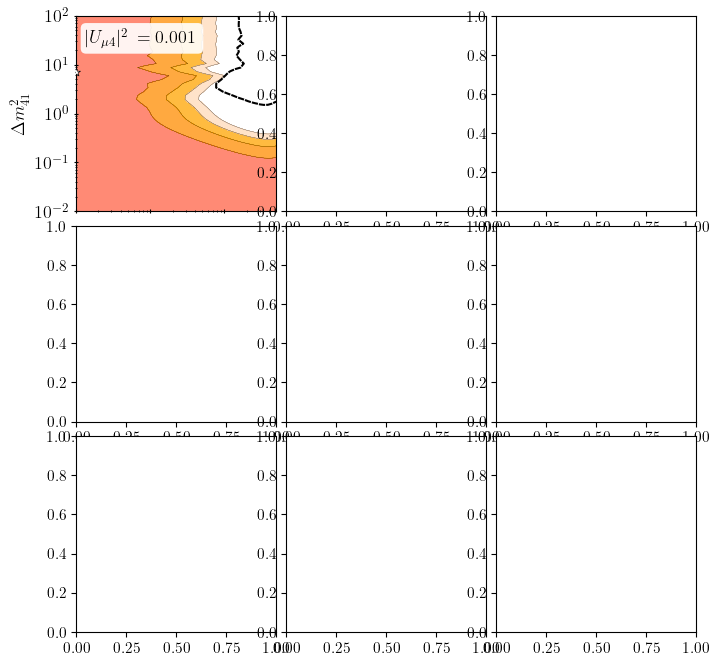

In [80]:
plot_all_slices('MH_numu_MC_keep_numu_norm', xi=2, yi=1, zi=3, global_deltachi2=False, asimov=False)

In [ ]:

# x,y=np.genfromtxt('OscTools/include/MB_data_release_2022/miniboone_fit_3sigma_1.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,1)))

# x,y=np.genfromtxt('OscTools/include/MB_data_release_2022/miniboone_fit_3sigma_2.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,1)), label=r'MB coll. - $3\sigma$')

# x,y=np.genfromtxt('OscTools/include/MB_data_release_2022/miniboone_fit_4sigma_1.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,0)))

# x,y=np.genfromtxt('OscTools/include/MB_data_release_2022/miniboone_fit_4sigma_2.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,0)), label=r'MB coll. - $4\sigma$')
